In [1]:
# install required libraries
!pip install transformers datasets torch scikit-learn pandas accelerate ipywidgets matplotlib

In [2]:
# import libs
import torch, pandas as pd, numpy as np, re, torch.nn as nn, wandb
from datetime import datetime
from tqdm.auto import tqdm
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [3]:
df = pd.read_csv("drive/MyDrive/cases.csv")

df.head(3) # civil = 0, criminal = 1, (legal_fees = 2)

,case_id,text,category,label,found_criminal_terms,found_civil_terms,source_file,word_count,char_count
0,/20867,Before us is a Petition for Review filed by pe...,CIVIL,0,NaN,negligence; reinstatement; administrative case,020867.json,2745,17441
1,/20873,Assailed in this Petition for Review on Certio...,CIVIL,0,NaN,civil case no.; civil action; quieting of title,020873.json,3990,25051
2,/20879,This is a Petition for Review under Rule 45 of...,CIVIL,0,NaN,negligence; nlrc; labor arbiter,020879.json,4815,31088


In [4]:
# data cleaning/preprocessing
tqdm.pandas()

# func
def clean_legal_text(text):
    """
    Comprehensive legal text cleaning function
    """
    if not isinstance(text, str):
        return ""

    # 1. Handle line breaks and tabs
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')

    # 2. Remove dates
    date_patterns = [
        r'\b\d{1,2}[-/]\d{1,2}[-/]\d{2,4}\b',  # DD-MM-YYYY
        r'\b\d{4}[-/]\d{1,2}[-/]\d{1,2}\b',    # YYYY-MM-DD
        r'\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]* \d{1,2},? \d{4}\b',
    ]
    for pattern in date_patterns:
        text = re.sub(pattern, '[DATE]', text, flags=re.IGNORECASE)

    # 3. Preserve legal punctuation but remove excessive special chars
    # Keep: . , ; : ? ! ( ) - [ ] { } " ' § ¶ @ # $ % & * + = < >
    text = re.sub(r'[^\w\s.,;:?!()\-\[\]{}"\'§¶@#$%&*+=<>]', ' ', text)

    # 4. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # remove numbers (keeps only words)
    text = ' '.join(re.findall(r"\d*[a-zA-Z][\w]*", text))

    return text



# call func
if 'text' in df.columns:
    df['cleaned_text'] = df['text'].apply(clean_legal_text)

    # Save result
    df.to_csv("cases_cleaned.csv", index=False)
    print("Cleaning complete! Saved to cases_cleaned.csv")

    # Show samples
    for i in range(2):
        print(f"\nSample {i}:")
        print(df['cleaned_text'].iloc[i][:300])

df.head(3)

Cleaning complete! Saved to cases_cleaned.csv

Sample 0:
Before us is a Petition for Review filed by petitioner Leticia A Cadena Cadena following the issuance by the Court of Appeals CA of its Decision dated DATE and Resolution dated DATE in the case docketed as CA G R SP No entitled Leticia A Cadena v Civil Service Commission The Factual AntecedentsCaden

Sample 1:
Assailed in this Petition for Review on Certiorari under Rule of the Rules of Court is the Decision of the Court of Appeals CAâ dated DATE in CA G R SP No as well as the Resolution dated DATE denying the motion for reconsideration thereof The dispositive portion of the assailed Decision reads WHEREF


,case_id,text,category,label,found_criminal_terms,found_civil_terms,source_file,word_count,char_count,cleaned_text
0,/20867,Before us is a Petition for Review filed by pe...,CIVIL,0,NaN,negligence; reinstatement; administrative case,020867.json,2745,17441,Before us is a Petition for Review filed by pe...
1,/20873,Assailed in this Petition for Review on Certio...,CIVIL,0,NaN,civil case no.; civil action; quieting of title,020873.json,3990,25051,Assailed in this Petition for Review on Certio...
2,/20879,This is a Petition for Review under Rule 45 of...,CIVIL,0,NaN,negligence; nlrc; labor arbiter,020879.json,4815,31088,This is a Petition for Review under Rule of th...


In [5]:
# stratified train-test split or stratified sampling (makes train and test split identical)

cleaned_df = pd.read_csv("cases_cleaned.csv")

train_df, test_df = train_test_split(
    cleaned_df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print(f"\nTrain:")
print(train_df["label"].value_counts(normalize=True))
print(f"\nTest:")
print(test_df["label"].value_counts(normalize=True))


Train:
label
0    0.903431
1    0.096569
Name: proportion, dtype: float64

Test:
label
0    0.903611
1    0.096389
Name: proportion, dtype: float64


In [6]:
# encode labels

label_encoder = LabelEncoder()
all_labels = pd.concat([train_df['label'], test_df['label']])
label_encoder.fit(all_labels)

train_df["label_encoded"] = label_encoder.transform(train_df["label"])
test_df["label_encoded"] = label_encoder.transform(test_df["label"])

label_encoder.classes_

array([0, 1])

In [7]:
# convert to huggingface dataset

train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(test_df)

In [8]:
# load lb tokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "nlpaueb/legal-bert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [9]:
# tokenize

def tokenize_function(examples):
    return tokenizer(
        examples["cleaned_text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
eval_tokenized = eval_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/12737 [00:00<?, ? examples/s]

Map:   0%|          | 0/3185 [00:00<?, ? examples/s]

In [10]:
# load legalbert

model = AutoModelForSequenceClassification.from_pretrained(
    "nlpaueb/legal-bert-base-uncased",
    num_labels=2 # 2 for Bi-Classification, 3 otherwise (with legal fees)
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/legal-bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
# training config

training_args = TrainingArguments(
    output_dir="./legalbert_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1, # change from 3-5 / if overfitting: 1-2
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="no",
    fp16=True
)

In [12]:
# metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",   # for imbalanced data
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }

In [13]:
weights = compute_class_weight(
    class_weight = 'balanced',
    classes=np.unique(train_df["label_encoded"]),
    y=train_df["label_encoded"]
)

# Convert to a Tensor and send to GPU/CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print(f"Weight for Civil (0): {weights[0]}")
print(f"Weight for Criminal (1): {weights[1]}")

Weight for Civil (0): 0.5534457286868862
Weight for Criminal (1): 5.177642276422764


In [14]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # Get predictions from Legal-BERT
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Tell the model to use the weights we calculated earlier
        # 'class_weights'
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [15]:
# train

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-838580603.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: peaksenut (peaksenut-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.273500,0.088990,0.994976,0.991232,0.979761,0.985411


TrainOutput(global_step=1593, training_loss=0.14244856708456527, metrics={'train_runtime': 391.5887, 'train_samples_per_second': 32.526, 'train_steps_per_second': 4.068, 'total_flos': 3351245512120320.0, 'train_loss': 0.14244856708456527, 'epoch': 1.0})

In [19]:
# 1. Run prediction on your evaluation set
output = trainer.predict(eval_tokenized)

# 2. Extract the ground truth labels
labels = output.label_ids

# 3. Extract the predictions (and take the argmax)
import numpy as np
preds = np.argmax(output.predictions, axis=-1)

# 4. Now your classification report will work!
from sklearn.metrics import classification_report

print(classification_report(labels, preds, target_names=["civil", "criminal"], digits=4))

              precision    recall  f1-score   support

       civil     0.9958    0.9986    0.9972      2878
    criminal     0.9866    0.9609    0.9736       307

    accuracy                         0.9950      3185
   macro avg     0.9912    0.9798    0.9854      3185
weighted avg     0.9950    0.9950    0.9949      3185



<Figure size 600x600 with 0 Axes>

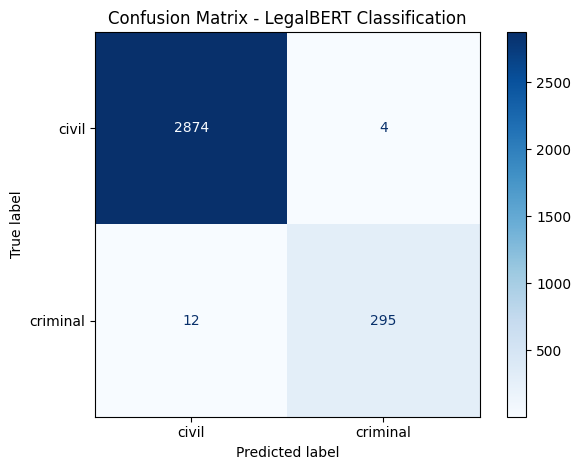

In [20]:
# confusion matrix

cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - LegalBERT Classification")
plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [21]:
classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

Device set to use cuda:0


In [22]:
# Generate timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")  # Format: 20240124_153045
model_path = f"models/{timestamp}/binary_legalbert_model_{timestamp}"

# Save
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)
print(f"Model saved to: {model_path}")

Model saved to: models/20260124_152458/binary_legalbert_model_20260124_152458
